# NumPy의 활용 

## 가우스 소거법(Gaussian Elimination)

우리는 다음과 같은 형태로 주어진 방정식을 선형방정식계라 합니다.

$$ 
\begin{cases}
a_{11}x_1 + a_{12}x_2 + \ldots + a_{1n}x_n = b_1 
\\ a_{21}x_1 + a_{22}x_2 + \ldots + a_{2n}x_n = b_2
\\ \vdots
\\ a_{n1}x_1 + a_{n2}x_2 + \ldots + a_{nn}x_n = b_n
\end{cases}
$$

이 때 당연히 계수 $a_{ij}$, $b_i$는 주어진걸로 전제하며, 우리는 위의 등식을 만족할 수 있는 미지수 $x_i$를 찾는 게 목적입니다.

위와 같은 선형 방정식계는 보통 다음과 같이 행렬과 벡터를 통해서 표현됩니다.

$$
\begin{pmatrix}
a_{11} & a_{12} & \ldots & a_{1n} \\
a_{21} & a_{22} & \ldots & a_{2n} \\
\vdots & \vdots & \ddots & \vdots \\
a_{n1} & a_{n2} & \ldots & a_{nn} \\
\end{pmatrix}
\begin{pmatrix}
x_1 \\
x_2 \\
\vdots \\
x_n \\
\end{pmatrix}
=\begin{pmatrix}
b_1 \\
b_2 \\
\vdots \\
b_n \\
\end{pmatrix}.
$$


이러한 방정식은 흔히 말하는 가우스 소거법으로 풀 수 있습니다. 가우스 소거법은 다음과 같은 과정을 의미합니다.

1. 우선 첫 번째 행을 $a_{11}$로 나누어, 기준이 되는 원소($a_{11}$)를 1로 만듭니다.
2. 그 후, 첫 번째 행에 적절한 상수를 곱해 다른 행들에서 빼줌으로써 $a_{11}$ 아래에 있는 모든 원소를 0으로 만듭니다.
4. 두 번째 행을 (변화된) $a_{22}$로 나누어, $a_{22}$의 자리를 1로 만듭니다.
5. 마찬가지로 두 번째 행을 이용해 그 아래에 있는 모든 원소를 0으로 소거합니다.
6. 이 과정을 모든 행에 대해 순차적으로 반복합니다. 총 $n-1$번의 단계를 거치면, 대각선 아래의 모든 원소가 0이 된 상삼각행렬 형태가 완성됩니다.
$$\begin{pmatrix}
1 & a'_{12} & a'_{13} & \ldots & a'_{1n} \\
0 & 1 & a'_{23} & \ldots & a'_{2n} \\
0 & 0 & 1 & \ldots & a'_{3n} \\
\vdots & \vdots & \vdots & \ddots & \vdots \\
0 & 0 & 0 & \ldots & 1 \\
\end{pmatrix}
\begin{pmatrix}
x_1 \\
x_2 \\
x_3 \\
\vdots \\
x_n \\
\end{pmatrix}
=
\begin{pmatrix}
b'_1 \\
b'_2 \\
b'_3 \\
\vdots \\
b'_n \\ \end{pmatrix}$$
이를 우리는 계단을 만드는 과정이라고도 합니다. 계단의 끝에 있는 0이 아닌 원소의 위치(1이 있는 지점)를 피봇(Pivot)이라고도 하구요.

8. 행렬이 상삼각행렬로 변환되었다면, 가장 마지막 줄은 $x_n = b_n'$ 형태가 되어 바로 해를 구할 수 있습니다.
9. 구해진 $x_n$을 바로 위의 방정식에 대입하여 $x_{n-1}$을 구하고, 이 과정을 위로 올라가며 반복하여 모든 미지수의 값을 찾아냅니다.

이 방법을 넘파이를 활용해서 구현해보겠습니다.

In [1]:
import numpy as np

이렇게 우선 넘파이를 임포트하고, 아래와 같이 `np.random.rand()`를 이용하여 랜덤 행렬 및 랜덤 변수를 정의합니다.

In [2]:
A = np.random.rand(4, 4)
b = np.random.rand(4)
A, b

(array([[0.42995642, 0.17551786, 0.11865752, 0.48674517],
        [0.70829206, 0.97030292, 0.38854194, 0.38857643],
        [0.9283111 , 0.03553808, 0.88131674, 0.54920824],
        [0.75359362, 0.19736772, 0.62794575, 0.69123245]]),
 array([0.00246322, 0.8983065 , 0.79097654, 0.90623954]))

우리는 우선 위의 가우스 소거법으로 선형 방정식을 푸는 수치적 알고리즘을 하나 만들고, 

이 `np.random.rand()`를 이용하여 랜덤한 행렬/벡터를 생성하여 그걸 이용해서 가우스 소거법 알고리즘을 테스트합니다.

우선 우리는 다음과 같이, 행렬 `A`의 `j`번째 계단을 만드는 알고리즘을 구현할 수 있습니다.

In [3]:
def eliminate(A, j):
    n = len(A)
    for i in range(j+1, n):
        A[i] = A[i] - A[j] * A[i,j] / A[j,j]
    return A

간단합니다. 우리는 결국 `j`행의 `j`열 원소 아래, 즉 `i = j+1,...,n`행의 `j`열 원소를 모두 0으로 만들어줘야하는데요,

이를 위해서 우리는 모든 `i`행에 `j`행에다가 $\frac{A[i,j]}{A[j,j]}$를 곱한 결과를 뺴줍니다.

$\frac{A[i,j]}{A[j,j]}$를 `j`행에 곱해버린다면, 그 결과물의 `j`열 원소는 항상 `i`행의 `j`열 원소가 일치하니, `i`행의 `j`열 성분이 0이 되겠죠.

In [4]:
print(A)
Anew = eliminate(A,0)
print(Anew)
print(eliminate(Anew,1))

[[0.42995642 0.17551786 0.11865752 0.48674517]
 [0.70829206 0.97030292 0.38854194 0.38857643]
 [0.9283111  0.03553808 0.88131674 0.54920824]
 [0.75359362 0.19736772 0.62794575 0.69123245]]
[[ 0.42995642  0.17551786  0.11865752  0.48674517]
 [ 0.          0.6811622   0.19307055 -0.413267  ]
 [ 0.         -0.34341936  0.62512544 -0.5017144 ]
 [ 0.         -0.11026612  0.41997223 -0.16189599]]
[[ 4.29956423e-01  1.75517865e-01  1.18657521e-01  4.86745166e-01]
 [ 0.00000000e+00  6.81162201e-01  1.93070551e-01 -4.13267004e-01]
 [ 0.00000000e+00  0.00000000e+00  7.22465202e-01 -7.10069900e-01]
 [ 0.00000000e+00  1.38777878e-17  4.51226371e-01 -2.28795395e-01]]


위에서도 보시다시피, 기존에는 꽉꽉차있던 `A`가, `eliminate()`를 사용할 때마다 각 열의 아랫 부분들이 지워지는걸 확인하실 수 있습니다.

그런데 저 친구는 아직 행렬 `A`의 모양만 바꾸지, `Ax = b` 자체를 바꾸진 않습니다.

선형대수학에서 우리는 $[ A\;|\;b]$형태로 확장된 행렬을 생각해서, 거기서 소거법을 이용했는데요,

이 과정은 다음과 같이 구현이 가능합니다.

In [5]:
def gauss(A,b):
    n = len(A)
    A = np.hstack([A, b.reshape(n,1)]) # hstack으로 A와 b를 가로로 순차시켜 확장된 행렬을 만듬.
    
    # 그리고 각 열에 대해서, eliminate()를 이용한 소거 과정을 구현함.
    for j in range(n-1):
        A = eliminate(A, j) 

    # 이 시점에서 A에는 기존의 확장된 행렬 [A|b]이 A가 상삼각 형태 A'가 된 [A'|b']가 들어있음.
    # 따라서 아래와 같이, A', b'를 따로 따로 반환함 :
    return A[:, :-1], A[:, -1]

간단합니다. 그냥 `hstack`, 즉 가로 방향으로 서로 다른 배열들을 쌓는 함수를 사용해서 확장된 행렬을 저렇게 만들고,

그리고 거기다가 eliminate를 해버리면 됩니다. 참고로 eliminate는 결국 $n\times n$ 행렬의 경우, 앞의 $n-1$개의 열에만 적용시키면 되기 떄문에

저렇게 `j`는 0부터 $n-2$까지 `for`문을 설정하셔야해요.

이 `for`문이 종료되는 시점에서는 결국 기존의 행렬 $A$가 상삼각 형태가 되는데요, 이 상삼각 형태를 $A'$라 하면,

위의 변수 `A`에 들어있는 친구는 대충 $[A'\;|\;b']$ 이렇게 적어줄 수 있습니다. $b'$는 `eliminate()`가 사용되며 기존의 $b$가 바뀐 형태를 의미하구요.

우리의 변수 `A`에는 지금 $[A'\;|\;b']$이런 형태의 친구들이 들어있어서, 위와 같이 각각 $A'$와 $b'$를 반환합니다.

이렇게 반환된 $A',b'$를 이용하면 우리는 아래에서부터 위까지 하나씩 미지수를 얻어내는 과정을 다음과 같이 반복할 수 있습니다.

In [6]:
def gauss_solve(A,b):
    A, b = gauss(A,b) # A,b에는 이 시점에 상삼각 형태의 A'x = b'가 남아있습니다.
    n = len(b)
    x = np.zeros(n) # 미지수를 넣기 위한 배열 x를 정의합니다.
    
    for i in range(n-1, -1, -1): # 가장 마지막(n-1번째 x)부터 하나씩 차례대로 미지수값을 x에 저장합니다.
        x[i] = (b[i] - A[i,:]@ x) / A[i,i]
    return x

상삼각 형태가 나온다면, 방정식의 $i$번째 행은 다음과 같습니다.
$$a_{i,i}x_i + a_{i,i+1}x_{i+1} + \dots + a_{i,n-1}x_{n} = b_i$$

이 시점에서 우리는 각 미지수를 거꾸로 구해내기 떄문에, $x_{i+1},...,x_n$값은 모두 알고 있으며, 이를 이용하여 $x_i$를 구해야합니다 :
$$a_{i,i}x_i = b_i - (a_{i,i+1}x_{i+1} + \dots + a_{i,n}x_{n})\quad \leftrightarrow \quad x_i = \frac{1}{a_{i,i}}\big(b_i - (a_{i,i+1}x_{i+1} + \dots + a_{i,n}x_{n})\big)$$
여기서 근데 우변의 괄호 안 $(a_{i,i+1}x_{i+1} + \dots + a_{i,n}x_{n})$이 친구는 결국 $i$행과 $x$와의 내적에 지나지 않습니다.

어차피 $x$에는 $i+1,...,n$번째 값들만 차있고, 나머지는 0이니, $A$의 $i$행과 $x$의 내적은 결국 저렇게

$A$의 $i$행의 각 성분을 $x$의 성분 $x_{i+1},...,x_n$에 순차적으로 곱하여 더한 형태가 될테니까요.

이 내적을 연산자 `@`로 구현한 게 위의 `x[i] = (b[i] - A[i,:]@ x) / A[i,i]` 코드가 되겠습니다.

여튼 이 과정을 모든 행 j에 대해서 반복한다면 우리는 해당 방정식의 해를 얻어낼 수 있습니다.

이걸 이용하면 아래와 같이 가우스 소거법으로 해를 구해낼 수 있습니다.

In [7]:
A = np.random.rand(3,3)
b = np.random.rand(3)
x = gauss_solve(A,b)
x

array([ 2.10961834, -3.64007463,  0.17512785])

실제로 다음과 같이 검산해보면 잘 작동하는걸 확인할 수 있어요.

In [8]:
A@x- b

array([5.55111512e-17, 1.11022302e-16, 0.00000000e+00])

## 선형방정식계를 위한 반복법

위의 가우스 소거법은 수치적인 방법이라기보다는, 우리가 손으로도 풀 수 있는 해석적인 방법을 그냥 알고리즘화한 형태라고 할 수 있습니다.

결국 진짜 수치를 구하는 방법은 맞지만, 그렇다고 접근 방식이 수치적이지는 않아요. 수치적인 방법이라고 한다면

우리가 생각하는건 보통 특정 오차 범위 내가 될 때까지 알고리즘을 반복하여 점점 정확한 해를 근사해나가는 과정이지만,

위의 가우스 소거법은 그냥 정해진 단계적인 알고리즘을 종료하면 끝나는 형태의 과정이기 떄문입니다.

가우스 소거법같은 방법은 커다란 행렬이 주어지는 경우에는 거의 사용 불가능할 정도로 성능이 낮다는 단점이 있습니다.

대신 수치적인 접근 방법 중 가장 대표적인 반복법을 사용하면 성능이 꽤 괜찮아요.

반복법도 똑같이 다음의 방정식을 풀기 위해 사용됩니다.

$$
A x = b,\quad \text{where }A\in\mathbb{R}^{n\times n},\; b\in\mathbb{R}^n
$$

우리가 이전에 뉴턴 방법 등을 다루면서 봤던 그 반복법과 똑같습니다. 그 반복법의 일종이에요.

기본적으로 선형방정식을 푸는 반복법은 다음 형태로 표현됩니다.

$$Mx_{n+1} = N x_n + b,\quad \text{for $x_0 \in \mathbb{R}^n$}$$

여기서 $M,N$은 $M-N = A$를 만족하는 적절한 행렬이고, $x_0$은 임의의 시작값입니다.

저런 방식으로 생성되는 수열 $(x_n)_{n\in\mathbb{N}}\subset \mathbb{R}^n$은 $M$이 가역이고, 다음이 만족되는 경우에 진짜 해로 수렴합니다.
$$
\;\forall y \in\mathbb{R}^n: \| M^{-1} N y\| \leq c \|y\|,\quad \text{for some $c \in (0,1)$}\quad \cdots(*)
$$ 
이 때, $\|\cdot\|$는 임의의 행렬 노름입니다.

저게 그럼 왜 수렴할까요? 그걸 확인하려면 오차를 고려하면 명확해집니다.

이제 실제 $Ax = b$의 해를 $x\in\mathbb{R}^n$이라 하고, 오차항 $e_n := x_n - x$를 정의하면 다음이 성립됩니다.

$$
\begin{aligned}
(I-M^{-1}A) e_{n} &= x_n - x - M^{-1} A x_n + M^{-1} A x
\\
&= x_n - x - x_n + M^{-1} N x_n + M^{-1} b
\\
&= M^{-1} N x_n + M^{-1} b - x = x_{n+1} - x = e_{n+1}.
\end{aligned}
$$

정의상 $A = M -N$이고, $M$이 가역이므로, $ M^{-1}A = I - M^{-1}N $이 성립되고, 이를 정리하면 $I-M^{-1}A = M^{-1}N$이 됩니다.

이걸 위의 관계에 넣어주면 다음이 유도됩니다.
$$
M^{-1}Ne_n = e_{n+1}
$$

따라서 $(*)$를 사용하면 다음이 성립되고,
$$
\Vert e_{n+1}\Vert = \Vert M^{-1}N e_{n}\Vert \leq c\cdot \Vert e_n\Vert
$$
$c<1$이 성립되므로, 결국 오차항이 $n\to\infty$에 대해 0으로 수렴합니다. 그 덕분에 수렴성이 보장되는거죠.

이러한 과정의 종료 조건으로 우리는 간단히 $r_n := b - Ax_n$의 노름을 사용합니다. 만약 $\|r_n\|$이 충분히 작다면 이는 $Ax \approx b$이니 중단하는거죠.

여담으로 $A$의 행렬 노름이 충분히 작은 경우, $\vert r_n\vert$ 자체가 위에서 다뤘던 실제 해와 수열간의 오차항의 역할을 할 수 있습니다.


결국 우리는 $M,N$, 특히나 $M$을 올바르게 골라야 저런 수렴성을 이야기할 수 있으므로, 반복법은 $M$을 어떻게 고르는지에 따라서 구분됩니다.

만약 $A$의 대각 성분만 떼온 형태의 $M$, 즉 `M = np.diag(np.diag(A))`을 고르는 경우, 우리는 이를 **야코비 방법**이라 합니다.

`diag(diag(A))`로 사용되는 이유는, 행렬을 입력하면 `diag`는 행렬의 대각 성분 벡터를 생성하므로, 그 벡터에 `diag`를 적용해서 대각 행렬을 만드는거죠.

그리고 상수 $\omega$에 대해서, $M = \frac{1}{\omega}I$를 고르는 방법을 우리는 **이완된 리차드슨 방법**이라고 합니다.

$\omega$는 이완 계수라고 하구요.

우선 야코비 방법은 다음과 같이 제네레이터를 이용하여 구현이 가능합니다.

In [9]:
def jacobi_gen(A,b,x0):
    N = -A.copy() # A = M - N이므로, N = M - A가 되기 떄문에, -A를 하나 복사해옵니다.
    
    for i in range(N.shape[0]): # 그리고 M은 A의 대각 성분으로 구성되므로,
        N[i,i] = 0              # N의 대각 성분들은 모두 0으로 만들어줍니다.
        
    x = x0
    while True:
        x = 1/np.diag(A) * (N @ x) + (1/np.diag(A)) * b # x_n+1 = M^{-1}Nx + M^{-1}b인데, M의 역수는 결국 대각 성분의 역수를 각 행에 곱하는거죠.
        yield x  # 각 수열을 하나씩 생성합니다.

# 위의 제너레이터를 이용하여 다음과 같이 허용 오차/최대 반복 횟수를 고정하여 수치적 과정을 진행합니다.

def jacobi(A,b,x0,tol=1e-6,n=100):
    g = jacobi_gen(A,b,x0)
    x = x0
    while np.linalg.norm(A @ x - b) > tol and n > 0: # 오차가 충분히 작아지거나, 최대 반복 횟수를 넘어가면 반복문 종료
        n -= 1
        x = next(g)
    return x

간단합니다. 결국 수학적인 설명은 위에서 했고, 그걸 그대로 구현한거 뿐입니다. 주석을 참고해주세요.

여튼 이걸 사용하면 다음과 같이 해를 구할 수 있습니다:

In [10]:
A = np.array([[5,1],[3,2]])
b = np.array([1,1])
x0 = np.array([1,1]) # 임의의 초기값
x =  jacobi(A,b,x0)
x

array([0.14285712, 0.28571408])

이제 실제로 `A@x - b`를 계산하면 다음과 같이 0에 가까운 값들이 나오는걸 확인할 수 있습니다.

In [11]:
A@x-b

array([-3.188646e-07, -4.782969e-07])

이제 리차드슨 방법도 비슷한 방법으로 구현 가능합니다. 하지만 이번엔 이완 계수도 전달받습니다 :

In [12]:
def richardson_gen(A,b,omega,x):
    while True:
        N = -A.copy() + 1/omega * np.eye(A.shape[0]) # N = M - A인데, M = 1/omega I이므로 N이 이렇게 정해집니다.
        x = omega * (N @ x) + omega * b
        yield x
    
def richardson(A,b,omega,x0,tol=1e-6,n=1000):
    g = richardson_gen(A,b,omega,x0)
    x = x0
    while np.linalg.norm(A @ x - b) > tol and n > 0:
        n -= 1
        x = next(g)
    return x

따라서 리차드슨 방법은 이완 계수가 어떤 친구가 전달되는지에 따라서 수렴 가능성이 결정됩니다.

이 떄문에 우리는 리차드슨을 사용할 때 오메가를 잘못 전달해서 수렴하지 않는 경우가 매우 잦습니다.

이를 확인하기 위해서 우리는 다음과 같이 익셉션을 정의할 수 있습니다.

In [13]:
class RichardsonError(Exception):
    def __init__(self, message):
        super().__init__(message)

이걸 이용하면 위의 `richardson()`함수를 다음과 같이 수정해줄 수 있습니다 :

In [14]:
def richardson_gen(A,b,omega,x):
    while True:
        N = -A.copy() + 1/omega * np.eye(A.shape[0]) # N = M - A인데, M = 1/omega I이므로 N이 이렇게 정해집니다.
        x = omega * (N @ x) + omega * b
        yield x
    
def richardson(A,b,omega,x0,tol=1e-6,n=1000):
    g = richardson_gen(A,b,omega,x0)
    x = x0
    while np.linalg.norm(A @ x - b) > tol and n > 0:
        n -= 1
        x = next(g)
    if n == 0 :
        raise RichardsonError("수렴점을 찾지 못했습니다.")
    return x

이제 만약 `n==0`, 즉 최대 반복 횟수를 도달했는데도 수렴하지 않는 경우에는 익셉션이 발생합니다 :

In [15]:
A = np.array([[5,1],[4,20]])
b = np.array([1,1])
x0 = np.array([1,1])
x = richardson(A,b,1,x0,n=10000)
a @ x

<class '__main__.RichardsonError'>: 수렴점을 찾지 못했습니다.

## 미분방정식

### 뉴턴의 냉각 법칙

뉴턴의 냉각 법칙은 시간 $t$에 따른 특정 대상의 온도 변화를 묘사하는 법칙입니다.

이 법칙에 따르면, 대상의 온도의 변화율(온도가 변하는 속도)은 대상과 그 대상의 주변 환경의 온도 차이에 비례하는 형태로 변합니다.

수학적으로 이는 다음과 같은 미분방정식으로 표현됩니다.

$$
\frac{d T(t)}{d t} = -\kappa \cdot (T(t) - T_{\infty}), 
$$

이 때, $T$는 대상의 온도를 시점 $t$에 표현하기 위한 함수이고, $T_\infty$는 주변 온도(상수)를 의미하며,

$\kappa$는 표면, 대류, 질량, 열전도계수 등에 의해 결정되는 상수로 생각하시면 됩니다.

미분 방정식은 결국 어떤 변화하는 대상(온도)에 대해서 대상의 변화율(온도 변화)이 주어졌을 떄, 그 대상 자체(온도)가 어떤 형태인지를 찾기 위한 방정식입니다.

기존의 대수 방정식이 어떤 수를 찾기 위한 방정식이라면, 미분 방정식은 함수의 변화 형태가 주어졌을 때, 원본 함수를 찾는 방정식인거죠.

해석적으로 해당 미분 방정식은 $t$에 대해 양 변을 적분하는 방법으로 풀 수 있습니다.

그 결과물은 다음과 같습니다 :
$$
T(t) = T_\infty+ (T_0 - T_\infty)*e^{(-\kappa \cdot t)},\quad \text{where } T_0 := T(t_0),\; t_0\geq 0
$$


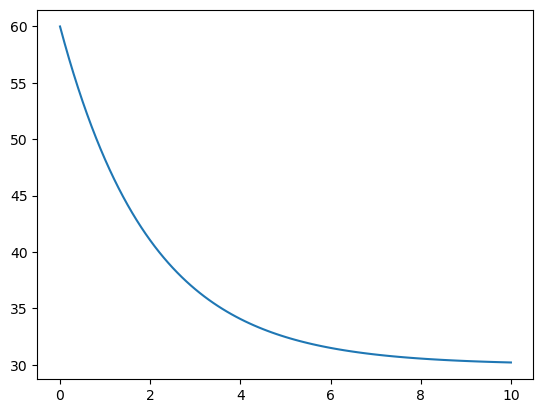

In [16]:
import numpy as np
import matplotlib.pyplot as plt

kappa = 0.5
T_inf = 30
T_0 = 60

def f(t):
    return T_inf + (T_0 - T_inf) * np.exp(-kappa * t)

t = np.linspace(0,10,101)
T = f(t)

plt.plot(t,T)

하지만 만약 $\kappa$가 상수가 아니라, 시간 $t$나 온도 함수 $T$, 아니면 심지어 이 둘 모두에 대해 의존적인 형태가 된다면,

이는 단순히 양 변을 적분하는 간단한 해석적 방법으론 풀 수 없습니다. 따라서 수치적인 방법을 사용하는데요,

아이디어는 간단합니다. 결국 $
\frac{d T(t)}{d t} = -\kappa \cdot (T(t) - T_{\infty}), 
$ 얘는 $T$의 도함수의 모양을 알려주는거잖아요? 근데 도함수는 대충 다음과 같이 근사가 가능하죠.
$$
\frac{\partial T(t)}{\partial t} \approx \frac{T(t) - T(t_0)}{t - t_0} \quad \text{for start point $t_0$}
$$

이를 이용하여 $-\kappa \cdot (T(t) - T_{\infty}) = \frac{T(t) - T(t_0)}{t - t_0}$를 $T$에 대해 정리하면 다음과 같습니다.

$$
T(t) = T_0 - (t - t_0)\kappa (T(t_0)-T_\infty), \quad \text{where $T_0 := T(t_0)$}
$$
참고로 위 식에서 우변의 $T(t_0)$는 원래 $T(t)$인데, 수치적 허용(?)으로 $T(t)$로 단순화한거로 생각하시면 됩니다.

이 단순화가 싫으시다면 그냥 한 단계 더 거쳐서 $T$로 정리하면 되는데 전 저 단순화 버젼을 사용할게요.

저 단순화를 기준으로 우리는 다음과 같은 공식을 사용하여 함수 $T$의 함수값들을 계산합니다 :


$$
T(t_{n+1}) = T_{n} - (t_{n+1}-t_{n})\kappa (T(t_n) - T_\inf), \quad \forall n\geq 0
$$

헷갈리실 수 있는 부분이, 우리는 지금 함수 $T$의 함수값을 근사로 계산하는겁니다. 저기에 등장하는 $t_n$들은 우리가 구하는 게 아니라,

임의로 배열 등으로 지정하는거에요. 예를 들어 $[0,10]$이라는 시간동안 $T$의 모양을 근사하고 싶다면,

$[0,10]$을 `linspace()`등으로 쪼개어, 각 점을 $t_n$으로 표현할 때, $t_{n+1}$ 시점에서 $T$의 함수값 $T(t_{n+1})$을 저 식으로 근사한다는거죠.

마치 $t_n$을 우리가 수렴해서 구하려는 대상으로 착각하실까봐 덧붙입니다.

이를 외재적 오일러 과정이라고도 합니다.

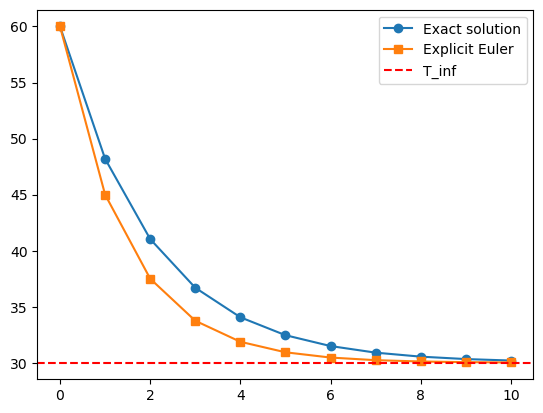

In [17]:
import numpy as np
import matplotlib.pyplot as plt

# 설정값
kappa = 0.5
T_inf = 30
T_0 = 60
N = 10
T_end = 10
dt = T_end / N

# 정의역을 쪼갭니다.
t = np.linspace(0, T_end, N + 1)

# 기존의 해석적인 해
T_ex = T_inf + (T_0 - T_inf) * np.exp(-kappa * t)

# 외재적 방법
T_euler = np.zeros(N + 1)
T_euler[0] = T_0

def f_prime(T): # 미분 방정식의 우변 (기울기 함수)
    return -kappa * (T - T_inf)

for n in range(N):
    T_euler[n+1] = T_euler[n] + dt * f_prime(T_euler[n])

# 그래프 출력 (x 대신 t 사용)
plt.plot(t, T_ex, label='Exact solution', marker='o')
plt.plot(t, T_euler, label='Explicit Euler', marker='s')
plt.axhline(T_inf, color='r', linestyle='--', label='T_inf')
plt.legend()
plt.show()

## 열전도 방정식(경계값 문제)

마지막으로 위 냉각 법칙처럼 온도에 관한 이야기를 하는 문제를 다뤄보도록 하겠습니다.

위에서 우리는 어떤 대상과 주변 환경의 온도를 생각해서 대상의 온도 변화를 모델링했는데요,

이제는 공간적인 온도 분포에 대한 이야기를 조금 해보려고 합니다.

우리 손에 길다란 막대가 있고, 이 막대의 특정 지점에 일정한 열을 가한 상황을 상상해보세요.

그리고 막대의 양 끝을 특정 고정된 온도를 가하여, 막대 전체를 냉각합니다.

열전도 방정식은 이 상황에서 외부의 영향을 아예 고려하지 않는 경우, 막대 내부의 열 분포가 어떨지의 의문을 수학적으로 모델링하는 미분 방정식입니다.

열전도 방정식은 일반적으로 편미분 방정식이라고 불리는 변수가 여러 개인 함수의 미분 방정식으로 모델링되는데요,

우리는 좀 더 문제를 단순화하여 간단한 경우만을 이야기하기 위해서 시간의 흐름에 따라서 막대의 온도가 더이상 변하지 않게되는 상태를 구해보려고 합니다.

즉, 우리는 열전도 방정식의 평형점(Equilibrium)을 생각해보려고 합니다.


이러한 문제는 다음과 같은 2계 상미분방정식(상미방인데, 좌변이 2계 도함수)으로 표현됩니다.
$$
\frac{d^2 T(x)}{d x^2} = -k \cdot f(x),
$$

기존에는 시간 $t$에 대한 온도를 생각했는데요, 우리는 막대기의 위치 $x$에 대한 온도를 생각합니다.

여기서 $T$는 막대의 온도, $f$는 열원/열침의 세기를 의미하며, $k$는 막대의 구성 물질의 열전도율을 표현하는 상수입니다.

열원은 막대에 열을 가하는 것(f가 양수가 되는 것)을 의미하며, 열침(f가 음수가 되는 것)은 열이 빠져나가는 것을 의미합니다.

단순화를 위해서 막대의 시작점 $x_0$과 끝점 $x_{end}$의 온도가 같고, 심지어 0도임을 $T(x_0) = T(x_{end}) = 0$임을 가정합니다.

막대의 길이는 $L:= x_{end} - x_0$으로 표현할 수 있는데요, 따라서 우리는 $[0,L]$에서 $T$가 어떤 형태가 되는지를 위의 2차 상미방으로 풀어야합니다.

이를 위해서 이 구간을 $N+1$개의 점으로 구성된 등거리 분할 $0 = : x_0< x_1 < ... < x_N := L$로 나눕니다.

그리고 각 분할의 간격을 $h>0$라 하면, 다시 위에서 했던거처럼, 우리는 위의 2계 도함수를 다음과 같이 근사할 수 있습니다.

$$
\frac{d^2 T(x_n)}{d^2 x} \approx \frac{\frac{d T(x_{n+1})}{dx} - \frac{d T(x_n)}{d x}}{x_{n+1}-x_n} 
=\frac{\frac{T(x_{n+1})-T(x_n)}{h} - \frac{T(x_n)-T(x_{n-1})}{h}}{h} 
= \frac{T(x_{n-1}) - 2 T(x_{n}) + T(x_{n+1})}{h^2},
$$

이걸 냉각 법칙떄처럼 위의 2계 미분 방정식에 넣어서 등식을 얻어낸 후, $T$값을 순서대로 생성할 수 있습니다.

$$
\frac{T(x_{n-1}) - 2 T(x_{n}) + T(x_{n+1})}{h^2} = -kf(x_n)
$$
여기서 더 단순화를 위해 $k = 1$을 가정하면 이 관계를 모든 $x_0,...,x_N$에 대해 다음으로 표현할 수 있습니다.

\begin{align*}
f(x_0) &= T(x_0) \\
f(x_1) &= -\frac{1}{h^2}(T(x_0) - 2T(x_1) + T(x_2))\\
f(x_2) &= -\frac{1}{h^2}(T(x_1) - 2T(x_2) + T(x_3))\\
\vdots &\\
f(x_{N-1}) &= -\frac{1}{h^2}(T(x_{N-2}) - 2T(x_{N-1}) + T(x_{N}))\\
f(x_N) &= T(x_{end}),
\end{align*}

우리는 $T(x_0) = T(x_{end})$임을 가정했는데요, 이렇게 미분방정식의 해의 양 끝 점의 조건을 우리는 경계값 조건이라 합니다.

따라서 위와 같은 미분방정식 문제를 경계값 문제라고도 합니다.

경계값 조건, 즉 경계 지점 $x_0, x_N$에서의 함수값은 우리가 정하는건데요, 따라서 나머지 $x_1,...,x_{N-1}$에서의 방정식들만 고려해도 충분합니다 :
\begin{align*}
f(x_1) &= -\frac{1}{h^2}(T(x_0) - 2T(x_1) + T(x_2))\\
f(x_2) &= -\frac{1}{h^2}(T(x_1) - 2T(x_2) + T(x_3))\\
\vdots &\\
f(x_{N-1}) &= -\frac{1}{h^2}(T(x_{N-2}) - 2T(x_{N-1}) + T(x_{N}))\\
\end{align*}

우리는 위의 등식들을 다음과 같이 변형할 수 있습니다.
$$\begin{cases}
-\frac{T(x_0) - 2T(x_1) + T(x_2)}{h^2} = f(x_1) \\
-\frac{T(x_1) - 2T(x_2) + T(x_3)}{h^2} = f(x_2)\\
\quad \vdots \\
-\frac{T(x_{N-2}) - 2T(x_{N-1}) + T(x_N)}{h^2} = f(x_{N-1})
\end{cases}$$

이 방정식을 우리는 다음과 같이 행렬 곱하기 벡터 형태의 **선형방정식** 형태로 표현할 수 있습니다 :
$$\frac{1}{h^2}
\begin{pmatrix}
2 & -1 & 0 & \cdots & 0 \\
-1 & 2 & -1 & \ddots & \vdots \\
0 & -1 & 2 & \ddots & 0 \\
\vdots & \ddots & \ddots & \ddots & -1 \\
0 & \cdots & 0 & -1 & 2
\end{pmatrix}
\begin{pmatrix} 
T(x_1) \\ T(x_2) \\ \vdots \\ T(x_{N-1}) 
\end{pmatrix} 
=\begin{pmatrix}
f(x_1) + \frac{1}{h^2} T(x_0) \\
f(x_2) \\
\vdots \\
f(x_{N-1}) + \frac{1}{h^2} T(x_N)
\end{pmatrix}$$

즉, 우리는 비선형적인 형태의 미분방정식의 해를 구하는 과정을 결국 위와 같은 선형방정식을 푸는 수치적 과정으로 생각할 수 있게 됩니다.

예시로 우리는 막대기의 길이가 $\pi$이고, 정확한 해는 $T(x) = \sin(x)$를 만족하며, 경계값을 모두 0으로 설정한 경우를 생각할 수 있습니다.

이 경우 열원/열침 함수 $f$는 다음의 형태가 됩니다.

$$
f(x) = -k \left(\frac{d}{dx^2}\sin(x)\right) = k \sin(x).
$$

우리는 이 $f$와 $k = 1$에 대해서 다음의 과정으로 $T$의 함수값들을 근사 가능합니다.

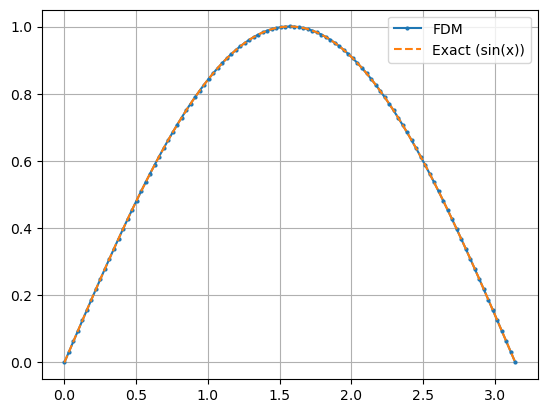

In [18]:
import numpy as np
import matplotlib.pyplot as plt

x_0 = 0
x_end = np.pi
N = 100 
h = (x_end - x_0)/N 

# 위 방정식의 좌변의 행렬 A를 생성
A = (1/h**2) * (2*np.eye(N-1) - np.eye(N-1, k=-1) - np.eye(N-1, k=1))

# 우변의 f들을 생성, T(x_0) = T(x_N) = 0인 전제라서, 얘네들은 안 더해줘도 됨.
f = np.zeros(N-1)
for n in range(N-1):
    f[n] = np.sin(x_0 + h*(n+1))

# 선방 풀이
T_interior = gauss_solve(A, f) 

# 경계점도 T에 추가
T = np.append(0, T_interior)
T = np.append(T, 0)

# 분할
x = np.linspace(x_0, x_end, N+1)
x_ex = np.linspace(x_0, x_end, 100)

# 플롯
plt.plot(x, T, label='FDM', marker='o', markersize=2)
plt.plot(x_ex, np.sin(x_ex), label='Exact (sin(x))', linestyle='--') # T'' = -sin(x)의 해는 sin(x)
plt.legend()
plt.grid(True)
plt.savefig('fdm_result.png', dpi=300, bbox_inches='tight')
plt.show()